## Analisi della densità polifonica ##
Questo notebook consente di analizzare la densità polifonica di una composizione<br>
restituendo grafici che indicano l'attività di ciascuna voce e il numero complessivo<br>
delle voci attive lungo la composizione

### Importazione ###
È necessario eseguire la prossima cella per caricare il codice che analizza<br>
le composizioni e genera i grafici.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display, HTML
import base64
from crim_intervals import importScore
import plotly.graph_objects as go

def download_html(fig, filename='chart.html'):
    b64 = base64.b64encode(fig.to_html(include_plotlyjs='cdn').encode()).decode()
    display(HTML(
        f'<a href="data:text/html;base64,{b64}" download="{filename}" '
        f'style="display:inline-block;margin-top:6px;padding:4px 14px;background:#4472C4;'
        f'color:#fff;border-radius:4px;text-decoration:none;font-size:12px;">⬇ {filename}</a>'
    ))

print('Ok')

Ok


#### Caricamento della composizione ###

In [2]:
path = 'Music_Files/'
filename = 'Marenzio_o_voi.xml' # ← cambia questo valore per caricare un altro file (usa le virgolette '')
url = path+filename
piece     = importScore(url)
print(piece.metadata)

{'title': 'O voi che sospirate', 'composer': 'Luca Marenzio', 'date': None}


#### Note ####

La funzione piece.notes() restituisce le note (e le pause) della composizione in forma di tabella.<br>
La tabella presenta una colonna per voce. Il valore sulla sinistra è l'offset,<br>
ossia il numero della semiminima in cui è presente la nota (o la pausa) corrispondente.<br>
La prima semiminimia è la numero 0.

In [3]:
n = piece.notes()
n

,Canto,Alto,Tenore,Quinto,Basso
0.0,Rest,Rest,Rest,Rest,E3
4.0,NaN,NaN,B3,NaN,NaN
8.0,E4,NaN,NaN,NaN,G#3
12.0,NaN,E4,C4,NaN,A3
16.0,G#4,NaN,B3,E3,Rest
...,...,...,...,...,...
438.0,C5,NaN,A3,NaN,A2
439.0,B4,NaN,B3,NaN,G#2
440.0,A4,NaN,C4,E3,A2
444.0,NaN,NaN,NaN,A3,NaN


La funzione piece.durations() restituisce le durate delle note della composizione.

In [4]:
d = piece.durations()
d

,Canto,Alto,Tenore,Quinto,Basso
0.0,8.0,12.0,4.0,16.0,8.0
4.0,NaN,NaN,8.0,NaN,NaN
8.0,8.0,NaN,NaN,NaN,4.0
12.0,NaN,8.0,4.0,NaN,4.0
16.0,4.0,NaN,4.0,8.0,1.0
...,...,...,...,...,...
438.0,1.0,NaN,1.0,NaN,1.0
439.0,1.0,NaN,1.0,NaN,1.0
440.0,8.0,NaN,8.0,4.0,8.0
444.0,NaN,NaN,NaN,4.0,NaN


#### Numero di voci attive ####

La funzione piece.soundingCount() restituisce il numero di voci attive in corrispondenza<br>
di ciascun 'evento', ossia di ciascun attacco di nota o pausa in ciascuna voce.<br>
Il valore 1 corrisponde a una voce attiva.

In [5]:
sound = piece.soundingCount()
sound

0.0      1
4.0      2
8.0      3
12.0     4
16.0     4
        ..
438.0    5
439.0    5
440.0    5
444.0    5
448.0    5
Name: Sounding, Length: 255, dtype: int64

Questa tabella può essere resa in forma di grafico a colonne grazie alla funzione plot.bar() di pandas.

doppio click sul grafico per ingrandire/rimpicciolire


<Axes: >

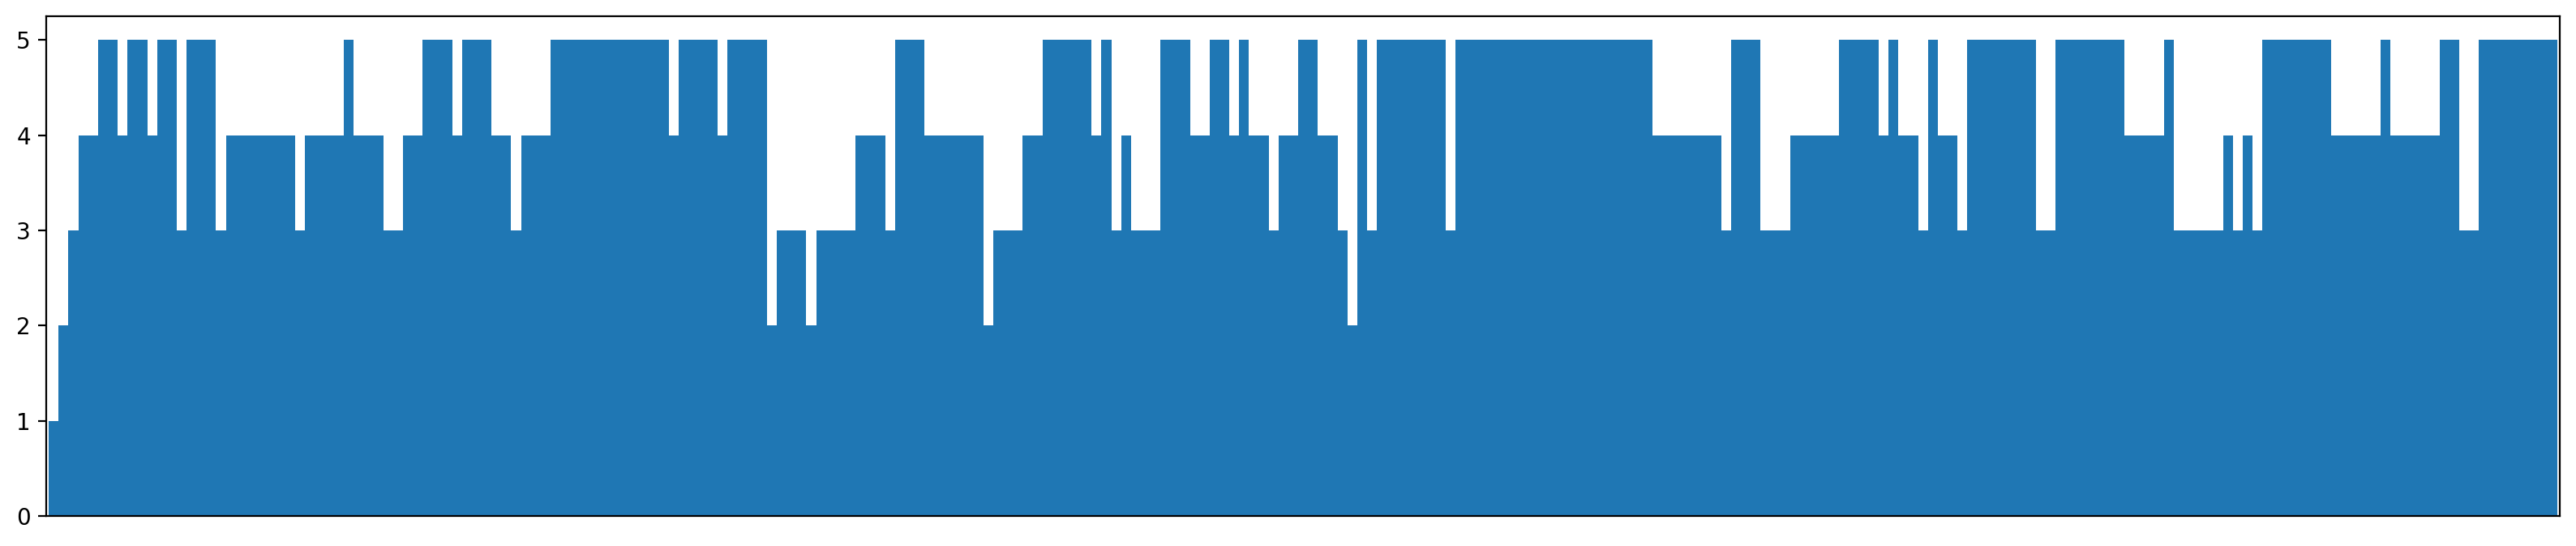

In [10]:
sound_plot = sound.plot.bar(figsize=(20, 4), width=1.0, xticks=[])
print('Doppio click sul grafico per ingrandire/rimpicciolire')
sound_plot


#### Cadenze ####

La funzione piece.cadences() individua le cadenze all'interno della composizione sulla base<br>
di alcuni pattern contrappuntistici predefiniti.<br>
Per ogni cadenza vengono indicate la tipologia, la sonorità di approdo e molte altre informazioni.

In [11]:
cad = piece.cadences()
cad

,CadType,LeadingTones,CVFs,Low,RelLow,Tone,RelTone,TSig,Measure,Beat,Sounding,Progress,SinceLast,ToNext
Last,,,,,,,,,,,,,,
44.0,Evaded Clausula Vera,-1,Tc,F#3,M2,NaN,NaN,4/2,6.0,3.0,3.0,0.098214,44.0,18.0
62.0,Evaded Clausula Vera,-1,Tc,B3,P5,NaN,NaN,4/2,8.0,4.0,3.0,0.138393,18.0,6.0
68.0,Evaded Clausula Vera,1,tCx,E3,P1,E,P8,4/2,9.0,3.0,4.0,0.151786,6.0,28.0
96.0,Evaded Clausula Vera,1,tC,B2,-P4,B,P5,4/2,13.0,1.0,5.0,0.214286,28.0,12.0
108.0,Authentic,1,CTB,B2,-P4,B,P5,4/2,14.0,3.0,5.0,0.241071,12.0,212.0
320.0,Clausula Vera,1,CT,A3,P4,A,P4,4/2,41.0,1.0,3.0,0.714286,212.0,52.0
372.0,Authentic,1,CB,G2,-M6,D,m7,4/2,47.0,3.0,5.0,0.830357,52.0,60.0
432.0,Abandoned Clausula Vera,-1,zy,C3,-M3,NaN,NaN,4/2,55.0,1.0,3.0,0.964286,60.0,24.0


In [ ]:
La funzione piece.cadenceProgressPlot() consente di visualizzare la successione delle cadenze<br>
lungo la composizione.<br>
I marcatori sono posizionati sull'asse y del grafico in base alla sonorità di approdo (Cadence Tone)<br>
e sull'asse x in base al punto in cui si trovano, espresso tramite un valore chiamato 'progress'<br>
e che indica la posizione di un evento (cadenza) tra il punto 0 della composizione (inizio)<br>
e il punto 1 (fine). I valori intermedi sono nomeri decimali.<br>
Quando la variabile includeType è impoistata su True i marcatori assumono forme diverse in base al tipo di cadenza.

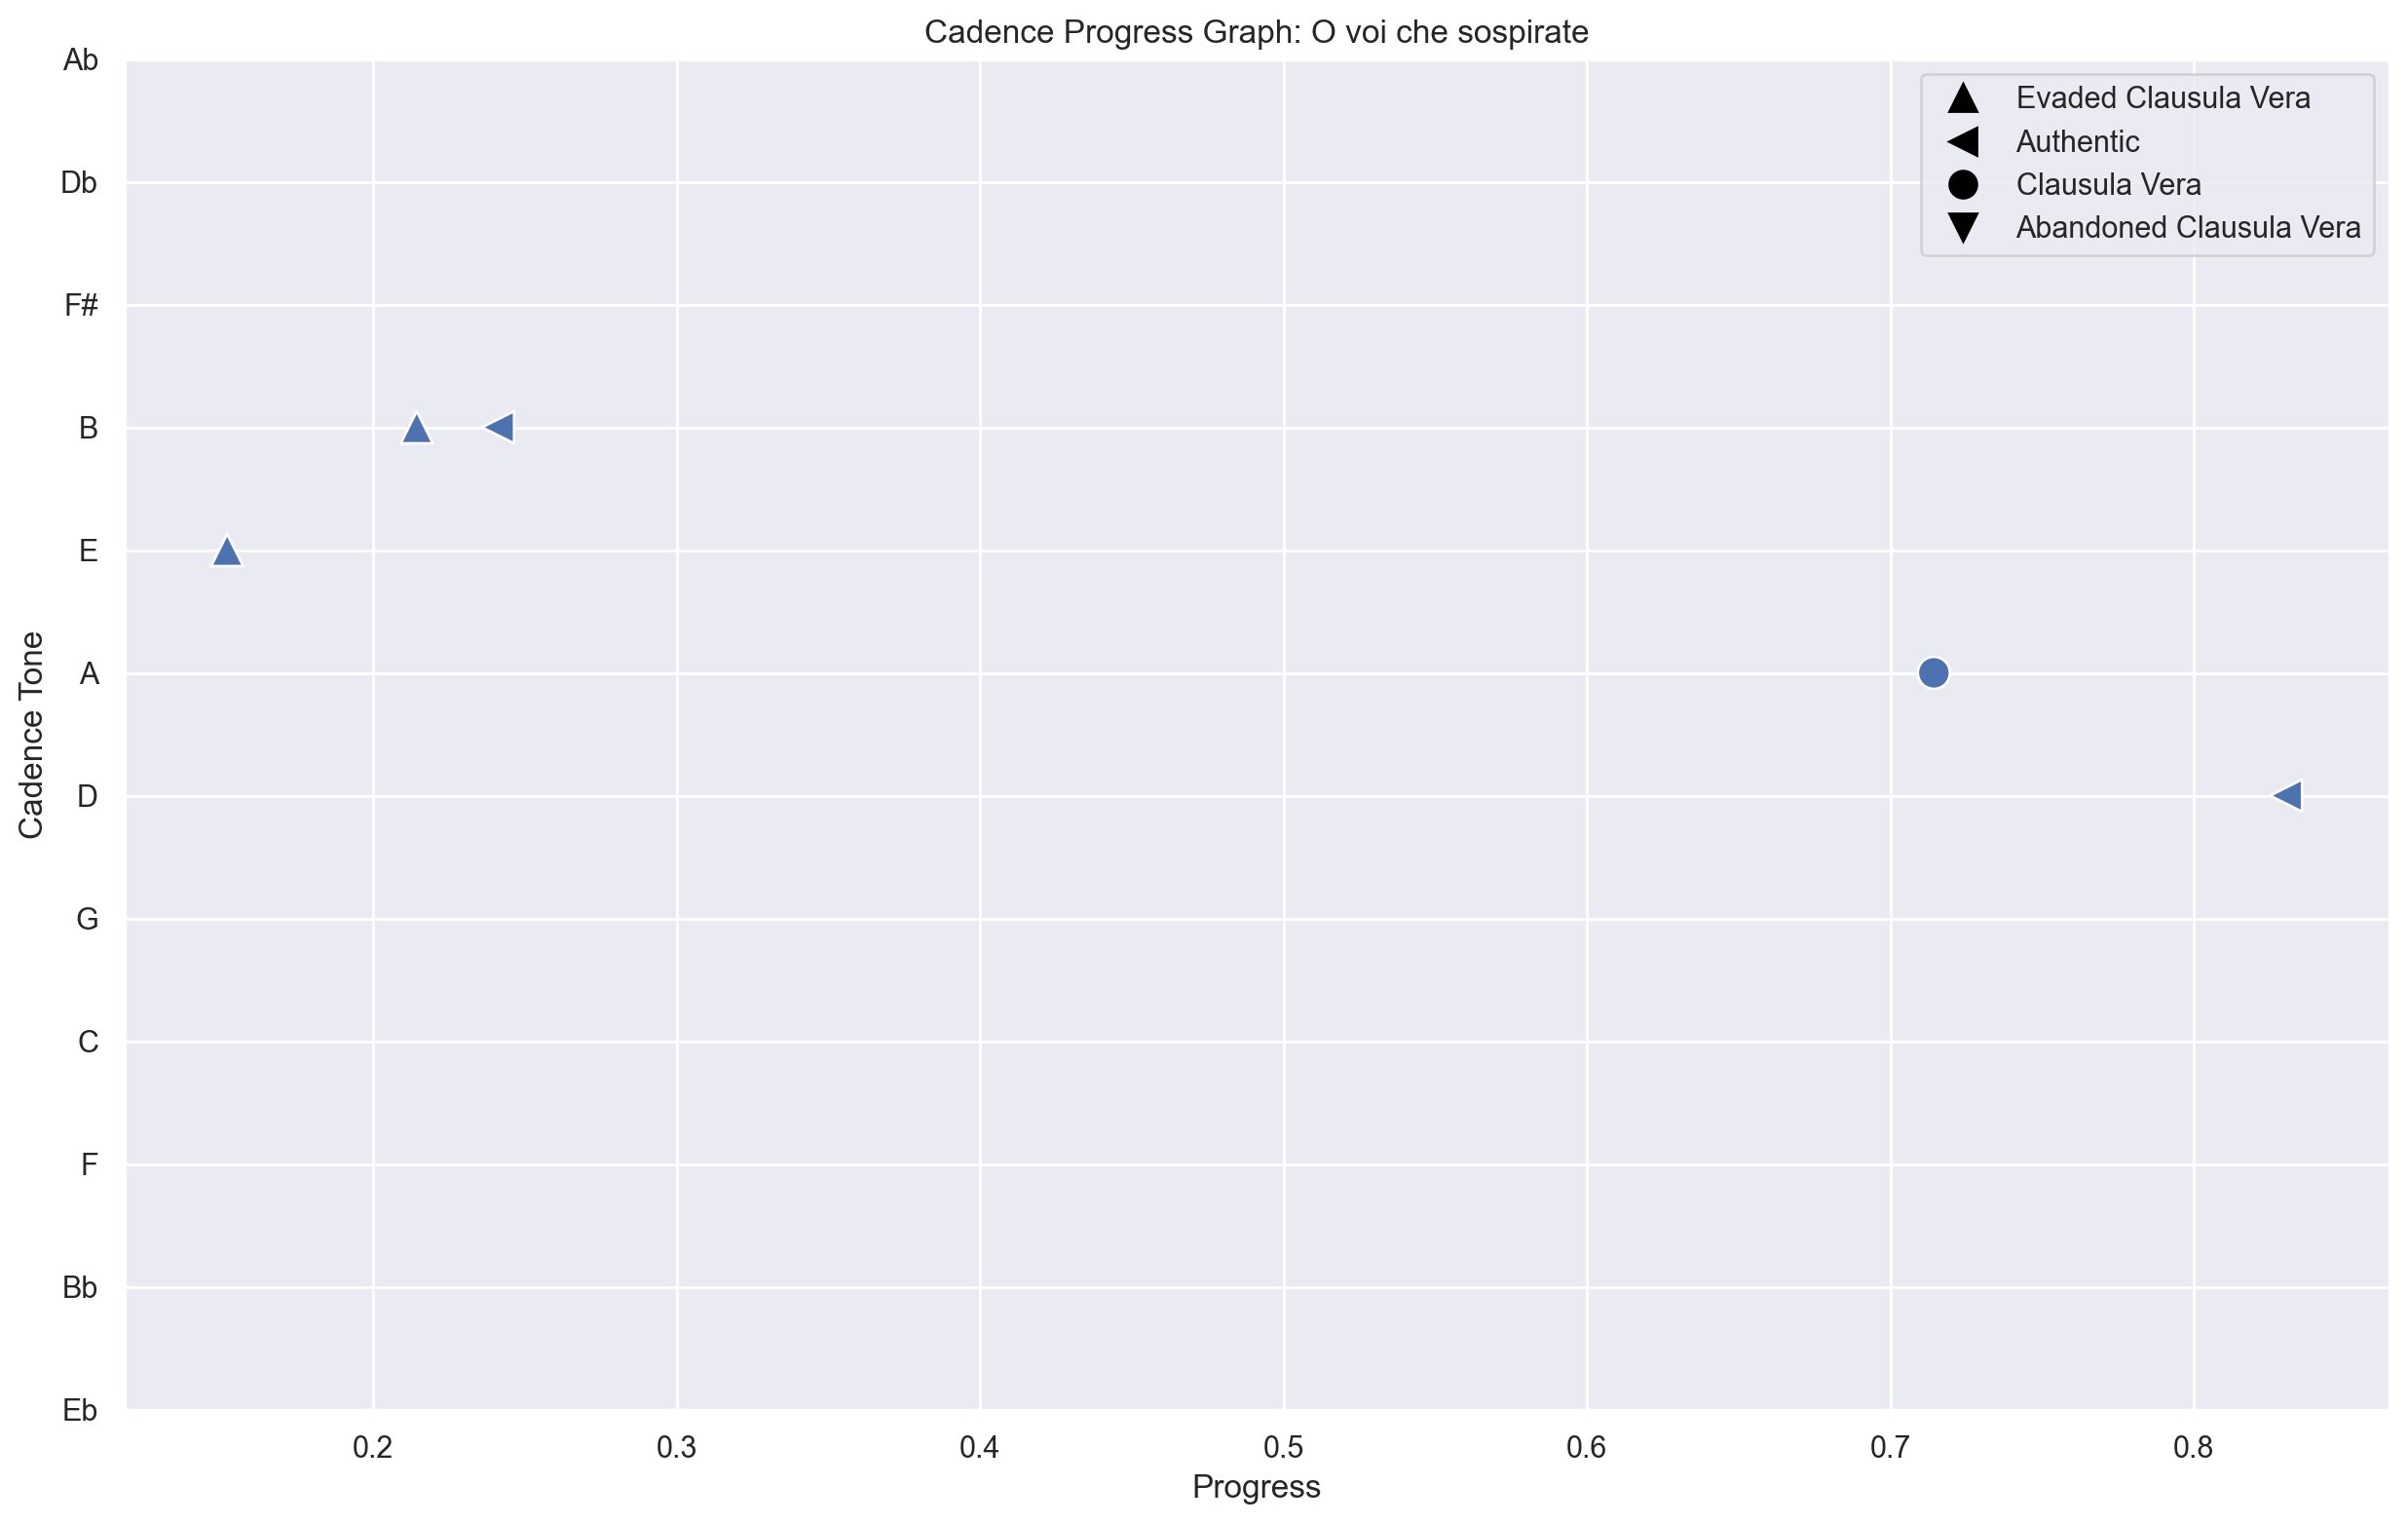

In [15]:
piece.cadenceProgressPlot(includeType=True)

In [16]:
cad = piece.cadences()
#types = ['FUGA']
# Filter rows where 'type' is in the list 'types'
#cad = cad[cad['Presentation_Type'].isin(types)]
link_cad = piece.linkExamples(df=cad, piece_url=url)

,CadType,LeadingTones,CVFs,Low,RelLow,Tone,RelTone,TSig,Measure,Beat,Sounding,Progress,SinceLast,ToNext
Last,,,,,,,,,,,,,,
44.0,Evaded Clausula Vera,-1,Tc,F#3,M2,NaN,NaN,4/2,6.0,3.0,3.0,0.098214,44.0,18.0
62.0,Evaded Clausula Vera,-1,Tc,B3,P5,NaN,NaN,4/2,8.0,4.0,3.0,0.138393,18.0,6.0
68.0,Evaded Clausula Vera,1,tCx,E3,P1,E,P8,4/2,9.0,3.0,4.0,0.151786,6.0,28.0
96.0,Evaded Clausula Vera,1,tC,B2,-P4,B,P5,4/2,13.0,1.0,5.0,0.214286,28.0,12.0
108.0,Authentic,1,CTB,B2,-P4,B,P5,4/2,14.0,3.0,5.0,0.241071,12.0,212.0
320.0,Clausula Vera,1,CT,A3,P4,A,P4,4/2,41.0,1.0,3.0,0.714286,212.0,52.0
372.0,Authentic,1,CB,G2,-M6,D,m7,4/2,47.0,3.0,5.0,0.830357,52.0,60.0
432.0,Abandoned Clausula Vera,-1,zy,C3,-M3,NaN,NaN,4/2,55.0,1.0,3.0,0.964286,60.0,24.0


#### Testo ####

La funzione piece.lyrics() restituisce in forma di tabella le sillabe<br>
associate a ciascuna nota della composizione.<br>

In [ ]:
lyr = piece.lyrics()
lyr

### Combinare i dati ###

I dati raccolti possono essere combinati all'interno di un'unica tabella.<br>
Questa verrà impiegata per generare un grafico arricchito con informazioni su<br>
note, durate, testo, numero delle voci attive e cadenze.

In [ ]:
n     = piece.notes()
d     = piece.durations()
sound = piece.soundingCount()

lyr         = piece.lyrics()
lyr_renamed = lyr.rename(columns={c: f'Lyric_{c}' for c in lyr.columns})

output = piece.detailIndex(
    df=pd.concat([n, d, sound, lyr_renamed], axis=1),
    progress=True
).reset_index()

output["Composer"] = piece.metadata['composer']
output["Title"]    = piece.metadata['title']
output["path"]     = Path(url).name

first_cols = ["Measure", "Beat", "Composer", "Title", "path"]
output = output[first_cols + [c for c in output.columns if c not in first_cols]]

cad = piece.cadences()
output = output.merge(
    cad[['Measure', 'Beat', 'CadType', 'Tone', 'CVFs']],
    on=['Measure', 'Beat'],
    how='left'
)

# ── Fix progress normalisation ─────────────────────────────────────────────────
# detailIndex normalises Progress as offset / last_event_offset, so the last
# note's bar starts at 1.0 and extends beyond — making it invisible.
# We renormalise so that piece_end (last offset + its max duration) maps to 1.0.
total_offsets = (d.index + d.max(axis=1)).max()   # actual piece end in offsets
output['Progress'] *= d.index.max() / total_offsets

output

## Analisi della densità polifonica ##

### Attività delle voci ###
L'asse y di questo grafico è popolata di tante righe quante sono le voci della composizione.<br>
L'asse x rappresenta il 'progresso' (progress) della composizione ossia il suo svolgimento<br>
dal punto 0 (inizio) al punto 1 (fine), con i valori intermedi espressi con numeri decimali.<br>
È presente anche un righello che indica il numero delle battute.

In [ ]:
# ── Detect voices: columns that appear AT LEAST TWICE are note+duration pairs ─
NON_VOICE = {'Measure', 'Beat', 'Composer', 'Title', 'path', 'Progress', 'Sounding'}
col_positions = {}
for i, col in enumerate(output.columns):
    if col in NON_VOICE:
        continue
    col_positions.setdefault(col, []).append(i)

voices, voice_note_col, voice_dur_col = [], {}, {}
for col, positions in col_positions.items():
    if len(positions) >= 2:
        voices.append(col)
        voice_note_col[col] = positions[0]
        voice_dur_col[col]  = positions[1]

# total_offsets and output['Progress'] are set correctly in the data prep cell
measure_map   = output.groupby('Measure')['Progress'].min()
measure_nums  = measure_map.index.tolist()
measure_progs = measure_map.values.tolist()

# ── Build figure ───────────────────────────────────────────────────────────────
palette = ['#4472C4','#ED7D31','#70AD47','#FFC000','#7030A0',
           '#FF6B6B','#00B0F0','#92D050','#FF00FF','#00B050']
fig = go.Figure()

for i, voice in enumerate(voices):
    n_col = output.iloc[:, voice_note_col[voice]]
    d_col = output.iloc[:, voice_dur_col[voice]]
    mask  = n_col.notna() & (n_col.astype(str) != 'Rest')
    idxs  = np.where(mask.values)[0]
    starts = output['Progress'].values[idxs]
    durs   = d_col.values[idxs].astype(float)

    lyr_key  = f'Lyric_{voice}'
    lyr_vals = (output[lyr_key].values[idxs].astype(str)
                if lyr_key in output.columns else np.full(len(idxs), ''))

    fig.add_trace(go.Bar(
        name=voice,
        x=(durs / total_offsets).tolist(),
        y=[voice] * len(idxs),
        base=starts.tolist(),
        orientation='h',
        marker=dict(color=palette[i % len(palette)], line=dict(width=0)),
        customdata=np.column_stack([
            output['Measure'].values[idxs].astype(int),
            output['Beat'].values[idxs],
            n_col.values[idxs].astype(str),
            durs,
            lyr_vals,
        ]),
        hovertemplate=(
            f'<b>{voice}</b><br>'
            'M %{customdata[0]}  b %{customdata[1]}<br>'
            'Pitch: %{customdata[2]}  Dur: %{customdata[3]:.0f}<br>'
            'Lyric: %{customdata[4]}<br>'
            '<extra></extra>'
        ),
    ))

# ── Cadence markers ────────────────────────────────────────────────────────────
cad_rows = output.dropna(subset=['CadType'])
cad_shapes = [
    dict(type='line', x0=row['Progress'], x1=row['Progress'], y0=0, y1=1,
         xref='x', yref='paper', line=dict(color='#c00', width=1, dash='dot'))
    for _, row in cad_rows.iterrows()
]
cad_annotations = [
    dict(
        x=row['Progress'], y=1, xref='x', yref='paper',
        text=row['CadType'] + (f"<br><b>{row['Tone']}</b>" if pd.notna(row['Tone']) else ''),
        showarrow=False, yanchor='bottom', xanchor='center',
        font=dict(size=7, color='#c00')
    )
    for _, row in cad_rows.iterrows()
]

fig.update_layout(
    title=f"{output['Title'].iloc[0]}  —  {output['Composer'].iloc[0]}",
    barmode='overlay',
    xaxis=dict(range=[0, 1], title='Progress', showgrid=False),
    yaxis=dict(title=None, categoryorder='array',
               categoryarray=list(reversed(voices))),
    height=150 + len(voices) * 45,
    showlegend=False,
    margin=dict(l=80, r=20, t=70, b=40),
    plot_bgcolor='white',
    shapes=[
        dict(type='line', x0=p, x1=p, y0=0, y1=1,
             xref='x', yref='paper', line=dict(color='#ddd', width=0.5))
        for p in measure_progs
    ] + cad_shapes,
    annotations=[
        dict(x=p, y=0, xref='x', yref='paper', text=str(int(m)),
             showarrow=False, yanchor='top', xanchor='center', font=dict(size=8))
        for m, p in zip(measure_nums, measure_progs) if m == 1 or m % 5 == 0
    ] + cad_annotations,
)
fig.show()
download_html(fig, 'voice_activity.html')

### Sonorità complessiva ###
L'asse x rappresenta il 'progresso' (progress) della composizione ossia il suo svolgimento<br>
dal punto 0 (inizio) al punto 1 (fine), con i valori intermedi espressi con numeri decimali.<br>
Le colonne lungo l'asse rappresentano il numero delle voci di volta in volta attive.

In [ ]:
# Sounding count — uses total_offsets / measure_nums / measure_progs / cad_* from above
df_s = (output[['Progress', 'Measure', 'Beat', 'Sounding']]
        .dropna(subset=['Sounding'])
        .reset_index(drop=True)
        .assign(Measure=lambda x: x['Measure'].astype(int)))

prog   = df_s['Progress'].values
gaps   = np.diff(prog)
widths = np.append(gaps, 1.0 - prog[-1])

fig_s = go.Figure(go.Bar(
    x=(prog + widths / 2).tolist(),
    y=df_s['Sounding'].tolist(),
    width=widths.tolist(),
    marker=dict(color='#4472C4', line=dict(width=0)),
    customdata=df_s[['Measure', 'Beat', 'Sounding']].values,
    hovertemplate=(
        'M %{customdata[0]}  b %{customdata[1]}<br>'
        'Sounding: %{customdata[2]:.0f}<br>'
        '<extra></extra>'
    ),
))

fig_s.update_layout(
    title='Sounding voices',
    xaxis=dict(range=[0, 1], title='Progress', showgrid=False),
    yaxis=dict(title='Active voices', dtick=1),
    height=250,
    showlegend=False,
    margin=dict(l=60, r=20, t=70, b=40),
    plot_bgcolor='white',
    bargap=0,
    shapes=[
        dict(type='line', x0=p, x1=p, y0=0, y1=1,
             xref='x', yref='paper', line=dict(color='#ddd', width=0.5))
        for p in measure_progs
    ] + cad_shapes,
    annotations=[
        dict(x=p, y=0, xref='x', yref='paper', text=str(int(m)),
             showarrow=False, yanchor='top', xanchor='center', font=dict(size=8))
        for m, p in zip(measure_nums, measure_progs) if m == 1 or m % 5 == 0
    ] + cad_annotations,
)
fig_s.show()
download_html(fig_s, 'sounding_voices.html')